Long/Short total : -6.1%
Long/Cash  total : -8.1%
Buy-and-hold     : -10.7%


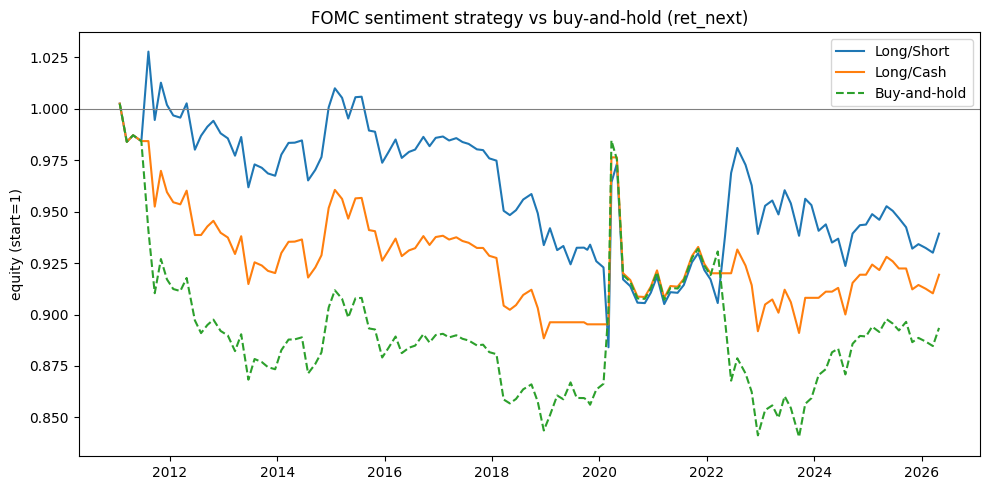

In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

bt = pd.read_csv("../data/processed/fomc_spy.csv", parse_dates=["date"])
bt = bt.sort_values("date").reset_index(drop=True)

# returns are decimals (std ~0.015), so NO /100
sig = np.sign(bt["sentiment"])
bt["pos_ls"] = sig                       # long/short: +1 / -1
bt["pos_lc"] = (sig > 0).astype(int)     # long/cash:  +1 / 0

bt["ls_ret"] = bt["pos_ls"] * bt["ret_next"]   # long/short strategy
bt["lc_ret"] = bt["pos_lc"] * bt["ret_next"]   # long/cash strategy
bt["bh_ret"] = bt["ret_next"]                  # buy-and-hold benchmark

for c in ["ls", "lc", "bh"]:
    bt[f"{c}_eq"] = (1 + bt[f"{c}_ret"]).cumprod() 

def tot(c): return (bt[f"{c}_eq"].iloc[-1] - 1) * 100
print(f"Long/Short total : {tot('ls'):+.1f}%")
print(f"Long/Cash  total : {tot('lc'):+.1f}%")
print(f"Buy-and-hold     : {tot('bh'):+.1f}%")

plt.figure(figsize=(10,5))
plt.plot(bt["date"], bt["ls_eq"], label="Long/Short")
plt.plot(bt["date"], bt["lc_eq"], label="Long/Cash")
plt.plot(bt["date"], bt["bh_eq"], label="Buy-and-hold", linestyle="--")
plt.axhline(1, color="gray", lw=0.8)   # break-even line
plt.legend(); plt.title("FOMC sentiment strategy vs buy-and-hold (ret_next)")
plt.ylabel("equity (start=1)"); plt.tight_layout(); plt.show()

Long/Short        : $9,393  (-6.1%)
Long/Cash         : $9,194  (-8.1%)
Proportional      : $9,065  (-9.3%)
FOMC-day-only hold: $8,935  (-10.7%)
True buy-and-hold : $72,208  (+622.1%)   [3837 trading days]


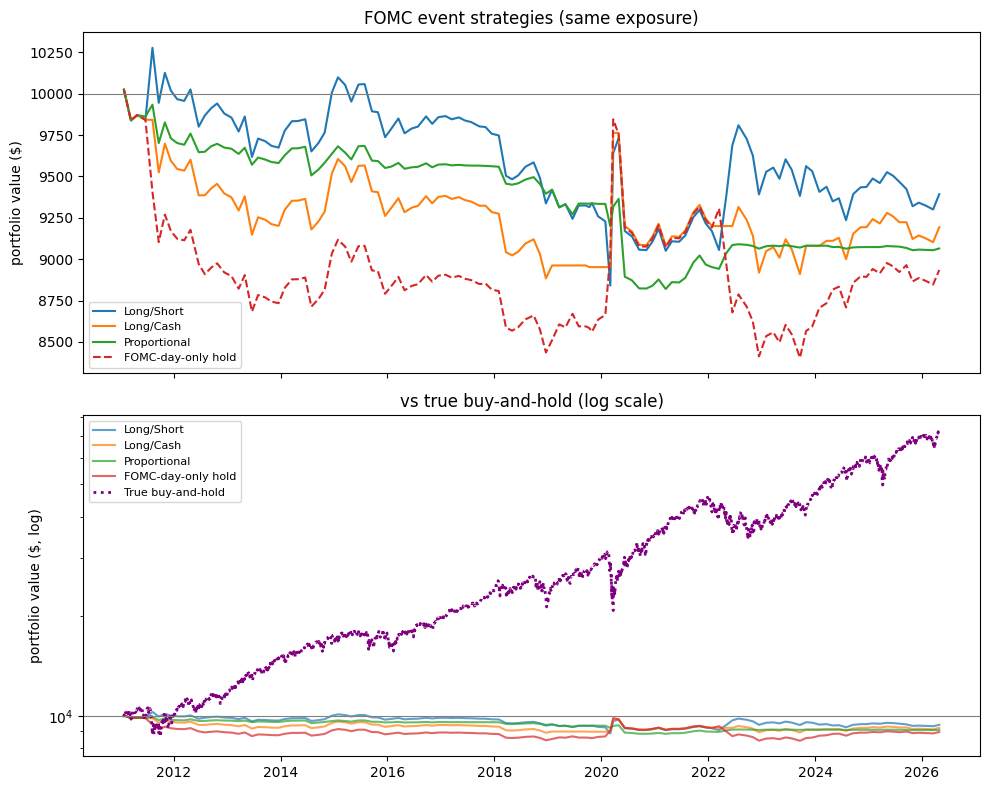

In [15]:
SEED = 10_000.0

# proportional sizing, leakage-free: scale by expanding max known up to time t
s = bt["sentiment"]
roll_max = s.abs().expanding().max()        # max of |sentiment| using only past+current
bt["pos_prop"] = (s / roll_max).fillna(0)   # scale so max conviction = +-1 exposure
bt["prop_ret"] = bt["pos_prop"] * bt["ret_next"]

# seed-money equity curves ($), compounded.
# NOTE: fomc_bh = holds ONLY on the 125 FOMC next-days, NOT true buy-and-hold
bt["ls_$"]      = SEED * (1 + bt["ls_ret"]).cumprod()
bt["lc_$"]      = SEED * (1 + bt["lc_ret"]).cumprod()
bt["prop_$"]    = SEED * (1 + bt["prop_ret"]).cumprod()
bt["fomc_bh_$"] = SEED * (1 + bt["bh_ret"]).cumprod()

# buy-and-hold: compound the ENTIRE daily SPY series over the same window
spy = pd.read_csv("../data/processed/spy_daily.csv", parse_dates=["Date"])
spy.columns = spy.columns.str.lower()       # known gotcha: mixed-case cols
spy = spy.sort_values("date").reset_index(drop=True)
mask = (spy["date"] >= bt["date"].min()) & (spy["date"] <= bt["date"].max())
spy_win = spy.loc[mask].copy()
spy_win["bh_$"] = SEED * (1 + spy_win["ret"].fillna(0)).cumprod()  # guard first NaN

def endval(c): return bt[f"{c}_$"].iloc[-1]
for name, c in [("Long/Short","ls"),("Long/Cash","lc"),
                ("Proportional","prop"),("FOMC-day-only hold","fomc_bh")]:
    print(f"{name:18s}: ${endval(c):,.0f}  ({(endval(c)/SEED-1)*100:+.1f}%)")
print(f"{'True buy-and-hold':18s}: ${spy_win['bh_$'].iloc[-1]:,.0f}  "
      f"({(spy_win['bh_$'].iloc[-1]/SEED-1)*100:+.1f}%)   [{len(spy_win)} trading days]")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# top: the 4 event strategies only — same exposure, apples-to-apples
for col, lab in [("ls_$","Long/Short"), ("lc_$","Long/Cash"),
                 ("prop_$","Proportional"), ("fomc_bh_$","FOMC-day-only hold")]:
    style = "--" if col == "fomc_bh_$" else "-"
    ax1.plot(bt["date"], bt[col], label=lab, linestyle=style)
ax1.axhline(SEED, color="gray", lw=0.8)
ax1.set_title("FOMC event strategies (same exposure)")
ax1.set_ylabel("portfolio value ($)"); ax1.legend(fontsize=8)

# bottom: everything incl. true B&H, log scale so +622% and -9% coexist
for col, lab in [("ls_$","Long/Short"), ("lc_$","Long/Cash"),
                 ("prop_$","Proportional"), ("fomc_bh_$","FOMC-day-only hold")]:
    ax2.plot(bt["date"], bt[col], label=lab, alpha=0.7)
ax2.plot(spy_win["date"], spy_win["bh_$"], label="True buy-and-hold",
         linestyle=":", color="purple", lw=2)
ax2.set_yscale("log")                       # log scale: ratios, not absolute gaps
ax2.axhline(SEED, color="gray", lw=0.8)
ax2.set_title("vs true buy-and-hold (log scale)")
ax2.set_ylabel("portfolio value ($, log)"); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

In [16]:
# risk-adjusted metrics for each strategy
# annualize by sqrt(8): roughly 8 FOMC meetings per year, 1-event holding period
PERIODS_PER_YEAR = 8

def metrics(pos, rets, eq):
    pos, rets, eq = np.asarray(pos), np.asarray(rets), np.asarray(eq)
    strat_ret = pos * rets

    # Sharpe on per-event returns (includes 0s for "didn't trade" events — honest)
    mu, sd = strat_ret.mean(), strat_ret.std(ddof=1)
    sharpe = (mu / sd) * np.sqrt(PERIODS_PER_YEAR) if sd > 0 else np.nan

    # max drawdown from equity curve: worst peak-to-trough
    dd = (eq / np.maximum.accumulate(eq) - 1).min()

    # hit rate / avg win / avg loss: only over events where we actually took a position
    active = pos != 0
    r_active = strat_ret[active]
    hit_rate = (r_active > 0).mean() if active.any() else np.nan
    avg_win  = r_active[r_active > 0].mean() if (r_active > 0).any() else np.nan
    avg_loss = r_active[r_active < 0].mean() if (r_active < 0).any() else np.nan
    n_trades = int(active.sum())

    return {"sharpe": sharpe, "max_dd": dd, "hit_rate": hit_rate,
            "avg_win": avg_win, "avg_loss": avg_loss, "n_trades": n_trades}

rows = []
for name, pos_col, ret_col, eq_col in [
    ("Long/Short",         "pos_ls",   "ls_ret",   "ls_$"),
    ("Long/Cash",          "pos_lc",   "lc_ret",   "lc_$"),
    ("Proportional",       "pos_prop", "prop_ret", "prop_$"),
    ("FOMC-day-only hold", None,       "bh_ret",   "fomc_bh_$"),
]:
    pos = bt[pos_col] if pos_col else pd.Series(np.ones(len(bt)))  # always-on for B&H
    m = metrics(pos, bt["ret_next"], bt[eq_col])
    rows.append({"strategy": name, **m})

mt = pd.DataFrame(rows).set_index("strategy")
mt_disp = mt.copy()
mt_disp["sharpe"]   = mt_disp["sharpe"].round(2)
mt_disp["max_dd"]   = (mt_disp["max_dd"]   * 100).round(1).astype(str) + "%"
mt_disp["hit_rate"] = (mt_disp["hit_rate"] * 100).round(1).astype(str) + "%"
mt_disp["avg_win"]  = (mt_disp["avg_win"]  * 100).round(2).astype(str) + "%"
mt_disp["avg_loss"] = (mt_disp["avg_loss"] * 100).round(2).astype(str) + "%"
print(mt_disp.to_string())
print("\nnote: Sharpe annualized by sqrt(8) — ~8 FOMC meetings/year.")
print("      hit_rate / avg_win / avg_loss computed over ACTIVE events only (pos != 0).")

                    sharpe  max_dd hit_rate avg_win avg_loss  n_trades
strategy                                                              
Long/Short           -0.07  -14.0%    48.0%   0.95%   -0.95%       125
Long/Cash            -0.12  -11.4%    48.1%   0.85%   -0.92%       104
Proportional         -0.31  -12.0%    48.0%    0.3%   -0.42%       125
FOMC-day-only hold   -0.15  -16.2%    48.8%   0.89%    -1.0%       125

note: Sharpe annualized by sqrt(8) — ~8 FOMC meetings/year.
      hit_rate / avg_win / avg_loss computed over ACTIVE events only (pos != 0).


Long/Short     actual=   -6.1%   perm mean=  -7.5%   perm 5/95%=[ -26.0%,  +12.2%]   p=0.442
Long/Cash      actual=   -8.1%   perm mean=  -8.5%   perm 5/95%=[ -18.5%,   +1.5%]   p=0.474
Proportional   actual=   -9.3%   perm mean=  -2.9%   perm 5/95%=[ -13.0%,   +7.3%]   p=0.846


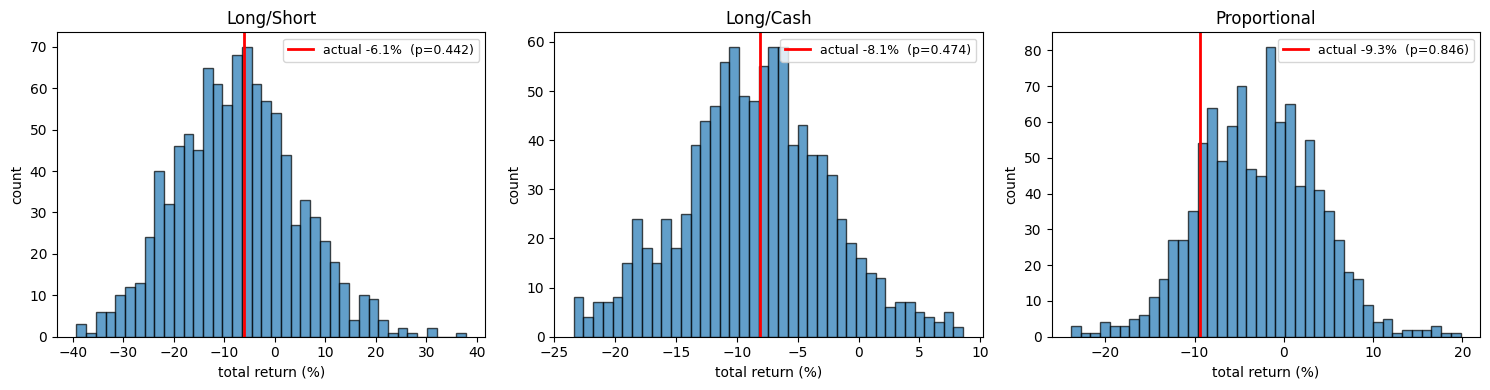


interpretation:
  p < 0.05  -> strategy clearly beats random sign assignment
  p ~ 0.50  -> indistinguishable from luck — the headline % is noise
  p > 0.95  -> inverted sign would have been the better choice


In [17]:
# permutation test: is the strategy's total return distinguishable from random?
# H0: positions carry no information -> permuting the position vector should
#     produce a return distribution centered on the true mean by chance alone.
# we shuffle pos, keep ret_next fixed, recompute total return N_PERM times.
# one-sided p = P(perm_return >= actual_return) under H0.
N_PERM = 1000
rng = np.random.default_rng(42)
rets = bt["ret_next"].to_numpy()

def total_return(pos, rets):
    return np.prod(1 + pos * rets) - 1

strategies = {
    "Long/Short":   bt["pos_ls"].to_numpy(),
    "Long/Cash":    bt["pos_lc"].to_numpy(),
    "Proportional": bt["pos_prop"].to_numpy(),
}

results = {}
for name, pos in strategies.items():
    actual = total_return(pos, rets)
    perms = np.array([total_return(rng.permutation(pos), rets) for _ in range(N_PERM)])
    p_val = (perms >= actual).mean()   # one-sided: is actual unusually HIGH?
    results[name] = {"actual": actual, "perms": perms, "p": p_val}
    print(f"{name:14s} actual={actual*100:+7.1f}%   "
          f"perm mean={perms.mean()*100:+6.1f}%   "
          f"perm 5/95%=[{np.percentile(perms,5)*100:+6.1f}%, "
          f"{np.percentile(perms,95)*100:+6.1f}%]   "
          f"p={p_val:.3f}")

# visualize: where does the real strategy sit in the null distribution?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    ax.hist(r["perms"]*100, bins=40, alpha=0.7, edgecolor="black")
    ax.axvline(r["actual"]*100, color="red", lw=2,
               label=f"actual {r['actual']*100:+.1f}%  (p={r['p']:.3f})")
    ax.set_title(name); ax.set_xlabel("total return (%)"); ax.set_ylabel("count")
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("\ninterpretation:")
print("  p < 0.05  -> strategy clearly beats random sign assignment")
print("  p ~ 0.50  -> indistinguishable from luck — the headline % is noise")
print("  p > 0.95  -> inverted sign would have been the better choice")